In [1]:
from scipy.stats import skewnorm
from numpy import array
import matplotlib.pyplot as plt
import numpy as np

In [6]:
modelParams = {'skewness': array([ 0.10943206, -0.37843434, -0.0989438 ]), 'locs': array([-0.3708732 ,  0.63102071,  2.32882062]),
 'scales': array([0.97970783, 0.97343459, 0.98588157]),
 'sample_weights': array([[5.07306960e-001, 4.56537897e-001, 3.61551437e-002],
       [3.73870179e-002, 6.87556042e-002, 8.93857378e-001],
       [2.87346228e-001, 4.45131813e-001, 2.67521958e-001],
       [4.62150652e-117, 1.28250219e-062, 1.00000000e+000]])}

trueParameters = dict(skewness = [0.1, 0.2, 0.3],
    loc = [0, 1, 2],
    scale = [1, 1.5, 1],
    sample_weights = array([[0.95, 0.05, 0],
                      [0, 0.25, 0.75],
                      [0.5, 0.5, 0],
                      [0, 0, 1]]))


In [15]:
skewnorm.cdf(x, modelParams['skewness'][0], modelParams['locs'][0], modelParams['scales'][0]).shape

(1000,)

In [20]:
(modelParams['sample_weights'][sampleNum][...,None] * np.stack([skewnorm.cdf(x, a, loc, scale) \
                                                                 for a, loc, scale in zip(modelParams['skewness'], modelParams['locs'], modelParams['scales'])],axis=0)).sum(0)

array([3.47823101e-07, 3.66234066e-07, 3.85580680e-07, 4.05908373e-07,
       4.27264670e-07, 4.49699280e-07, 4.73264193e-07, 4.98013776e-07,
       5.24004891e-07, 5.51296945e-07, 5.79952083e-07, 6.10035250e-07,
       6.41614320e-07, 6.74760226e-07, 7.09547086e-07, 7.46052335e-07,
       7.84356871e-07, 8.24545191e-07, 8.66705551e-07, 9.10930113e-07,
       9.57315114e-07, 1.00596103e-06, 1.05697276e-06, 1.11045979e-06,
       1.16653641e-06, 1.22532186e-06, 1.28694059e-06, 1.35152245e-06,
       1.41920288e-06, 1.49012317e-06, 1.56443070e-06, 1.64227914e-06,
       1.72382876e-06, 1.80924663e-06, 1.89870696e-06, 1.99239131e-06,
       2.09048894e-06, 2.19319709e-06, 2.30072127e-06, 2.41327561e-06,
       2.53108321e-06, 2.65437645e-06, 2.78339737e-06, 2.91839803e-06,
       3.05964093e-06, 3.20739936e-06, 3.36195783e-06, 3.52361254e-06,
       3.69267174e-06, 3.86945626e-06, 4.05429995e-06, 4.24755016e-06,
       4.44956827e-06, 4.66073019e-06, 4.88142692e-06, 5.11206509e-06,
      

In [23]:
def get_empirical_cdf(u):
    nu = len(u)
    empirical_cdf = np.linspace(0,1,nu) + (1/nu)
    return empirical_cdf

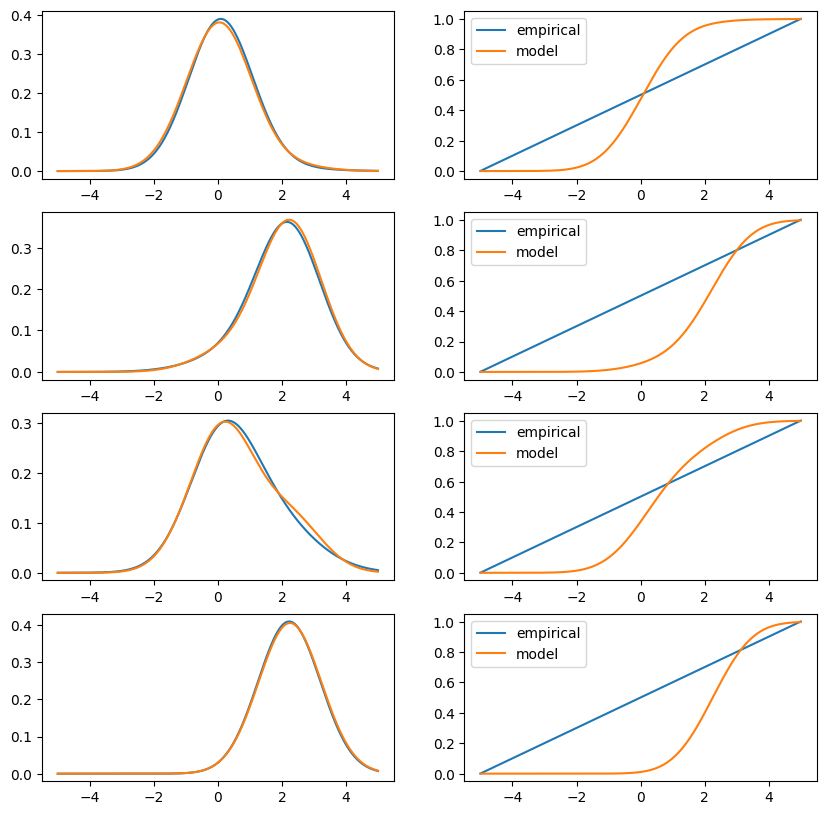

In [24]:
fig,ax = plt.subplots(len(trueParameters['sample_weights']), 2, figsize=(10, 10))
x = np.linspace(-5, 5, 1000)
for sampleNum in range(len(trueParameters['sample_weights'])):
    f = np.sum(trueParameters['sample_weights'][sampleNum][...,None] * [skewnorm.pdf(x, a, loc, scale) for a, loc, scale in zip(trueParameters['skewness'], trueParameters['loc'], trueParameters['scale'])], axis=0)
    g = np.sum(modelParams['sample_weights'][sampleNum][...,None] * [skewnorm.pdf(x, a, loc, scale) for a, loc, scale in zip(modelParams['skewness'], modelParams['locs'], modelParams['scales'])], axis=0)
    # empirical_cdf = np.arange(1, len(f)+1) / len(f)

    model_cdf = (modelParams['sample_weights'][sampleNum][...,None] * np.stack([skewnorm.cdf(x, a, loc, scale) \
                                                                 for a, loc, scale in zip(modelParams['skewness'], modelParams['locs'], modelParams['scales'])],axis=0)).sum(0)
    ax[sampleNum,0].plot(x, f)
    ax[sampleNum,0].plot(x, g)
    ax[sampleNum,1].plot(x, get_empirical_cdf(x), label='empirical')
    ax[sampleNum,1].plot(x, model_cdf, label='model')
    ax[sampleNum,1].legend()

In [ ]:
uscores = 